In [157]:
import os
import sys
from pathlib import Path
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from attention import self_attention, positional_encoding
import matplotlib.pyplot as plt
import seaborn as sns

TOKEN_TO_IDX = {"X": 0, "O": 1, "_": 2}
RESULT_TO_IDX = {"X": 1, "O": -1, "_": 0}  # for game result
X = "X"
O = "O"
EMPTY = "_"
cwd = Path().resolve().parent.parent

TRAINING_DATA_FILE_PATH = "./data_generation_script/mcts_training_alphazero_data.json"


In [123]:
def load_training_data(file_path):
    if not os.path.exists(file_path):
        raise ValueError("File does not exists")
    with open(file_path, "r") as f:
        data = json.load(f)

    if not data:
        raise ValueError("No data")
    return data


In [124]:
training_data = load_training_data(TRAINING_DATA_FILE_PATH)

batch_zero = training_data[0]
batch_zero

[{'board': ['_', '_', '_', '_', '_', '_', '_', '_', '_'],
  'move': 0,
  'pi': [0.05, 0.1, 0.15, 0.15, 0.1, 0.1, 0.1, 0.15, 0.1],
  'turn': 'X',
  'result': '_'},
 {'board': ['X', '_', '_', '_', '_', '_', '_', '_', '_'],
  'move': 1,
  'pi': [0, 0.05, 0.1, 0.1, 0.1, 0.15, 0.2, 0.15, 0.15],
  'turn': 'O',
  'result': '_'},
 {'board': ['X', 'O', '_', '_', '_', '_', '_', '_', '_'],
  'move': 7,
  'pi': [0, 0, 0.1, 0.25, 0.15, 0.15, 0.1, 0.15, 0.1],
  'turn': 'X',
  'result': '_'},
 {'board': ['X', 'O', '_', '_', '_', '_', '_', 'X', '_'],
  'move': 3,
  'pi': [0, 0, 0.3, 0.15, 0.1, 0.15, 0.15, 0, 0.15],
  'turn': 'O',
  'result': '_'},
 {'board': ['X', 'O', '_', 'O', '_', '_', '_', 'X', '_'],
  'move': 6,
  'pi': [0, 0, 0.25, 0, 0.15, 0.25, 0.2, 0, 0.15],
  'turn': 'X',
  'result': '_'},
 {'board': ['X', 'O', '_', 'O', '_', '_', 'X', 'X', '_'],
  'move': 8,
  'pi': [0, 0, 0.35, 0, 0.15, 0.35, 0, 0, 0.15],
  'turn': 'O',
  'result': '_'},
 {'board': ['X', 'O', '_', 'O', '_', '_', 'X', 'X', 

# Data Preparation

- For training convert them to proper tensor
- Compute z from turn and result for each timestep: +1 if current player won, -1 if lost, 0 if draw.
- Convert all continuous values (pi, z) to float32 to match network output dtype.


In [125]:
for row in training_data:
    for col in row:
        col["board_indices"] = torch.tensor([TOKEN_TO_IDX[val] for val in col["board"]])
        col["result_index"] = torch.tensor(RESULT_TO_IDX[col["result"]])
        col["move"] = torch.tensor(col["move"])

        if col["result"] == col["turn"]:
            col["z"] = torch.tensor(1, dtype=torch.float32)
        elif col["result"] == EMPTY:
            col["z"] = torch.tensor(0, dtype=torch.float32)
        else:
            col["z"] = torch.tensor(-1, dtype=torch.float32)

        col["pi"] = torch.tensor(col["pi"], dtype=torch.float32)
        col["turn"] = torch.tensor(TOKEN_TO_IDX[col["turn"]])

In [126]:
flat_data = []
for game in training_data:
    for move in game:
        flat_data.append(move)

In [127]:
len(flat_data)

6483

In [128]:
class TTTDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]

In [129]:
flat_data[0]

{'board': ['_', '_', '_', '_', '_', '_', '_', '_', '_'],
 'move': tensor(0),
 'pi': tensor([0.0500, 0.1000, 0.1500, 0.1500, 0.1000, 0.1000, 0.1000, 0.1500, 0.1000]),
 'turn': tensor(0),
 'result': '_',
 'board_indices': tensor([2, 2, 2, 2, 2, 2, 2, 2, 2]),
 'result_index': tensor(0),
 'z': tensor(0.)}

In [130]:
spilt = int(0.8 * len(flat_data))
train_data = flat_data[:spilt]
val_data = flat_data[spilt:]
train_loader = DataLoader(TTTDataset(train_data), batch_size=1, shuffle=True)
val_loader = DataLoader(TTTDataset(val_data), batch_size=1, shuffle=False)

# Model Building


In [142]:
EMBEDDING_DIM = 16  # higher value for proper caputring of dim relationship
SEQ_LENGTH = 9  # board's state for a tic tac toe
VOCAB_SIZE = 3  # 3 possible board states: empty(_), X, O


class AlphaZeroTicTacToeTransformer(nn.Module):
    def __init__(self, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self.W_Q = nn.Parameter(torch.randn(EMBEDDING_DIM, EMBEDDING_DIM))
        self.W_K = nn.Parameter(torch.randn(EMBEDDING_DIM, EMBEDDING_DIM))
        self.W_V = nn.Parameter(torch.randn(EMBEDDING_DIM, EMBEDDING_DIM))
        self.embeddings = nn.Embedding(VOCAB_SIZE, EMBEDDING_DIM)

        self.policy_layer = nn.Linear(EMBEDDING_DIM, 1)

        self.value_layer = nn.Linear(EMBEDDING_DIM, 1)

    def forward(self, x: torch.Tensor):
        x = self.embeddings(x)
        x = x + positional_encoding(x).to(x.dtype)
        # outputs.shape = [seq_length X embed dim]
        # attn_weights.shape = [seq_length X seq_length]
        # outputs= updates embeddings, each pos carries relation info
        # attn_weights carries strength of relationships inbetween every pair pos
        outputs, attn_weights = self_attention(x, self.W_Q, self.W_K, self.W_V)

        # value head: winning prob given board state (-1 to +1)
        value_pred = outputs.mean(dim=0)
        value_pred = self.value_layer(value_pred)
        value_pred = torch.tanh(value_pred).squeeze(-1)

        # policy head: possible moves with prob, this is the outputlayer [SEQ_LEGNTH,]
        # return raw logits for now
        policy_logits = self.policy_layer(outputs)
        policy_log_probs = torch.log_softmax(policy_logits.squeeze(-1), dim=-1)

        # print("attn output shape", outputs.shape)
        # print("attn weights shape", attn_weights.shape)
        return (
            policy_log_probs,
            value_pred,
            attn_weights,
        )

In [133]:
policy_layer = nn.Linear(16, 1)
input = torch.randn(9, 16)
input = input.mean(dim=0)
print("input shape after mean accross column", input.shape)
policy_layer = policy_layer(input)
print("policy_Layer", policy_layer.shape)
output = torch.tanh(policy_layer)
print(input, "\n", output.shape)
output

input shape after mean accross column torch.Size([16])
policy_Layer torch.Size([1])
tensor([ 0.1361,  0.2065, -0.1246,  0.2014, -0.0155,  0.6579,  0.2656, -0.1016,
        -0.0046, -0.3023, -0.1795, -0.3805,  0.0116,  0.2228, -0.4526,  0.9012]) 
 torch.Size([1])


tensor([-0.4910], grad_fn=<TanhBackward0>)

In [134]:
policy_layer = nn.Linear(16, 1)
input = torch.randn(9, 16)
policy_layer = policy_layer(input).squeeze(1)
print("policy_Layer:", policy_layer.shape, policy_layer)
output = torch.softmax(policy_layer, dim=0)
print("output:", output.shape, output)

policy_Layer: torch.Size([9]) tensor([-0.2102,  0.7486,  0.0883,  0.1997, -0.4437,  0.5549, -0.2294,  1.3840,
         0.7218], grad_fn=<SqueezeBackward1>)
output: torch.Size([9]) tensor([0.0560, 0.1461, 0.0755, 0.0844, 0.0444, 0.1204, 0.0550, 0.2759, 0.1423],
       grad_fn=<SoftmaxBackward0>)


In [136]:
test = AlphaZeroTicTacToeTransformer()
x = torch.tensor([2, 2, 2, 2, 2, 2, 2, 2, 2])
p, v, _ = test(x)
p

attn output shape torch.Size([9, 16])
attn weights shape torch.Size([9, 9])


tensor([-2.8267, -2.7898, -2.8561, -3.0145, -3.0707, -2.9084, -1.1377, -1.4020,
        -2.2521], grad_fn=<LogSoftmaxBackward0>)

In [104]:
nn.Linear(16, 1)

Linear(in_features=16, out_features=1, bias=True)

In [143]:
model = AlphaZeroTicTacToeTransformer()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)
value_criterion = nn.MSELoss()


# Model Training

## Loss Function:

$$l = (z - v)^2 - \pi^\top \log p + c||\theta||^2$$


In [144]:
train_losses = []
val_losses = []

for epoch in range(20):
    epoch_loss = 0.0
    for data in train_loader:
        x = data["board_indices"].squeeze(0)  # add batch dimension

        z = data["z"]
        pi = data["pi"]

        optimizer.zero_grad()
        p, v, _ = model(x)
        value_loss = value_criterion(v, z)
        policy_loss = -torch.sum(pi * p)

        loss = value_loss + policy_loss

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()  # accumulate batch loss

    # These lines are **after the inner loop**, still inside epoch loop
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data in val_loader:
            x = data["board_indices"].squeeze(0)
            z = data["z"]
            pi = data["pi"]
            p, v, _ = model(x)
            value_loss = value_criterion(v, z)
            policy_loss = -torch.sum(pi * p)

            loss = value_loss + policy_loss
            val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
    model.train()

    print(
        f"Epoch {epoch + 1} - Training Loss: {avg_train_loss:.4f} Validation loss:{avg_val_loss:.4f}"
    )


Epoch 1 - Loss: 3.0937 Validation loss:2.8825
Epoch 2 - Loss: 2.7675 Validation loss:2.7435
Epoch 3 - Loss: 2.6870 Validation loss:2.7062
Epoch 4 - Loss: 2.6625 Validation loss:2.6968
Epoch 5 - Loss: 2.6512 Validation loss:2.6915
Epoch 6 - Loss: 2.6469 Validation loss:2.6936
Epoch 7 - Loss: 2.6443 Validation loss:2.6820
Epoch 8 - Loss: 2.6422 Validation loss:2.6824
Epoch 9 - Loss: 2.6420 Validation loss:2.6805
Epoch 10 - Loss: 2.6396 Validation loss:2.6804
Epoch 11 - Loss: 2.6393 Validation loss:2.6827
Epoch 12 - Loss: 2.6370 Validation loss:2.6750
Epoch 13 - Loss: 2.6365 Validation loss:2.6795
Epoch 14 - Loss: 2.6354 Validation loss:2.6788
Epoch 15 - Loss: 2.6332 Validation loss:2.6905
Epoch 16 - Loss: 2.6353 Validation loss:2.6722
Epoch 17 - Loss: 2.6339 Validation loss:2.6740
Epoch 18 - Loss: 2.6349 Validation loss:2.6753
Epoch 19 - Loss: 2.6331 Validation loss:2.6750
Epoch 20 - Loss: 2.6330 Validation loss:2.6714


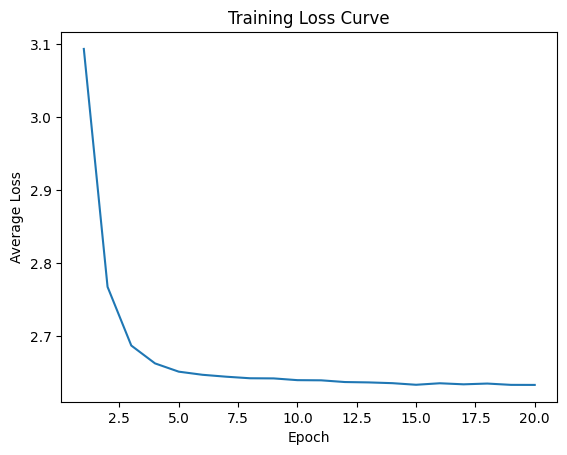

In [145]:
plt.plot(range(1, len(train_losses) + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss Curve")
plt.show()


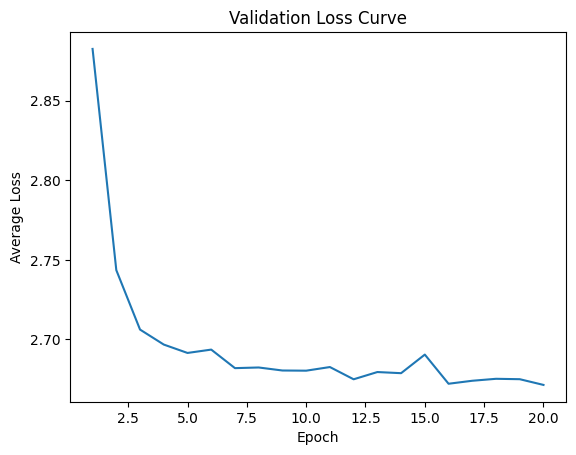

In [146]:
plt.plot(range(1, len(val_losses) + 1), val_losses)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Validation Loss Curve")
plt.show()

In [159]:
# code for saving model
torch.save(model.state_dict(), "alphazero_tictactoe.pth")

# Model Evaluation

In [151]:
model = AlphaZeroTicTacToeTransformer()
model.load_state_dict(torch.load("alphazero_tictactoe.pth"))
model.eval()


def predict_move(model, board):
    indices = torch.tensor([TOKEN_TO_IDX[s] for s in board])

    model.eval()
    with torch.no_grad():
        log_probs, value, _ = model(indices)
        print(log_probs)
    # mask illegal moves (non-empty cells)
    for i, cell in enumerate(board):
        if cell != "_":
            log_probs[i] = float("-inf")

    move = torch.argmax(log_probs).item()
    return move


In [152]:
# O about to win - model should block at position 2
board = ["O", "O", "_", "X", "X", "_", "_", "_", "_"]
print(predict_move(model, board))  # should return 2 or 5

# X about to win - model should play position 2
board = ["X", "X", "_", "O", "O", "_", "_", "_", "_"]
print(predict_move(model, board))  # should return 2

tensor([-13.8261, -13.8261,  -1.5787,  -9.1060,  -9.0526,  -1.6865,  -1.6374,
         -1.5819,  -1.5688])
8
tensor([-23.6112, -23.6102,  -1.6147, -21.1825, -21.1825,  -1.5993,  -1.6185,
         -1.6188,  -1.5961])
8


In [ ]:
boards = {
    "empty": ["_", "_", "_", "_", "_", "_", "_", "_", "_"],
    "X about to win": ["X", "X", "_", "O", "O", "_", "_", "_", "_"],
    "midgame": ["X", "O", "_", "_", "X", "O", "_", "_", "_"],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, board) in zip(axes, boards.items()):
    indices = torch.tensor([TOKEN_TO_IDX[s] for s in board])
    model.eval()
    with torch.no_grad():
        logits, weights = model(indices)

    weight_matrix = weights
    cell_labels = [f"{s} ({i})" for i, s in enumerate(board)]

    im = ax.imshow(weight_matrix, cmap="hot")
    ax.set_xticks(range(9))
    ax.set_yticks(range(9))
    ax.set_xticklabels(cell_labels, fontsize=8)
    ax.set_yticklabels(cell_labels, fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [ ]:
import random
from data_generation_script.uct_mcts import MCTSNode
from data_generation_script.tic_tac_toe import Tictactoe
from copy import deepcopy


mcts_agent = game.O
ai_agent = game.X

print(f"mcts_agent: {mcts_agent} and ai_agent:{ai_agent}")
results = {"X": 0, "O": 0, "draw": 0}
for _ in range(100):
    game = Tictactoe()
    while not game.is_gameover():
        if game.turn == ai_agent:
            move = predict_move(model, game.board)
            game.make_move(move)
        else:
            root = MCTSNode(state=game)
            mcts_best_move = root.best_action(simulations_number=500)
            # print("===mcts best move===", mcts_best_move)
            game.make_move(mcts_best_move)

    # print("\n\nFinal Board:")
    # game.print_board()

    if game.winner == game.X:
        results["X"] += 1
        # print("X won!")
    elif game.winner == game.O:
        results["O"] += 1
        # print("O won!")
    else:
        results["draw"] += 1
        # print("Draw!")

In [ ]:
print(f"mcts_agent: {mcts_agent} and ai_agent:{ai_agent}")
results

In [ ]:
torch.save(model.state_dict(), "tictactoe_transformer_model.pth")

In [154]:
target_board = ["O", "O", "_", "X", "X", "_", "_", "_", "_"]
for game in training_data:
    for move in game:
        if move["board"] == target_board:
            print(move["pi"])

In [155]:
print(predict_move(model, ["O", "X", "_", "_", "_", "X", "O", "_", "_"]))

tensor([-18.5997, -18.5776,  -1.6095,  -1.6094,  -1.6094, -14.3822, -18.5996,
         -1.6095,  -1.6094])
8


In [156]:
board = ["O", "X", "_", "_", "_", "X", "O", "_", "_"]
indices = torch.tensor([TOKEN_TO_IDX[s] for s in board])
with torch.no_grad():
    log_probs, value, _ = model(indices)
print(log_probs)
print(value)

tensor([-18.5997, -18.5776,  -1.6095,  -1.6094,  -1.6094, -14.3822, -18.5996,
         -1.6095,  -1.6094])
tensor(0.1222)


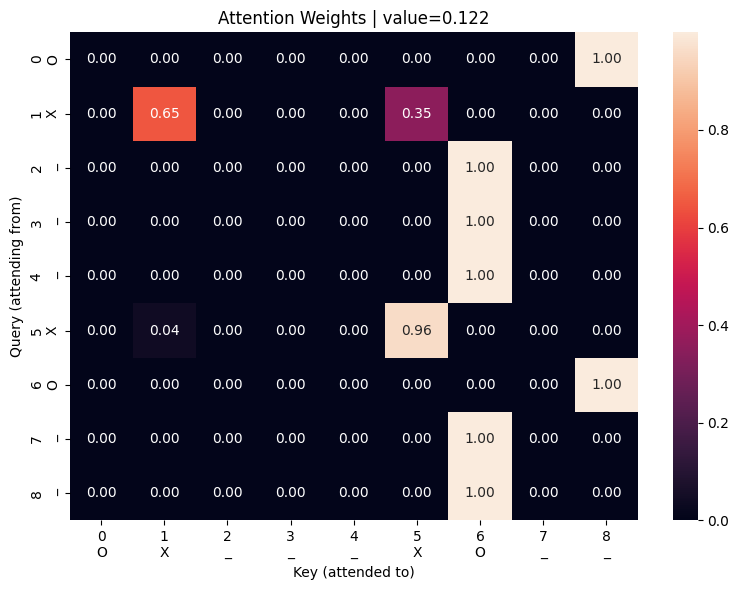

In [158]:
board = ["O", "X", "_", "_", "_", "X", "O", "_", "_"]
indices = torch.tensor([TOKEN_TO_IDX[s] for s in board])

with torch.no_grad():
    log_probs, value, attn_weights = model(indices)

plt.figure(figsize=(8, 6))
sns.heatmap(
    attn_weights.numpy(),
    annot=True,
    fmt=".2f",
    xticklabels=[f"{i}\n{board[i]}" for i in range(9)],
    yticklabels=[f"{i}\n{board[i]}" for i in range(9)],
)
plt.title(f"Attention Weights | value={value.item():.3f}")
plt.xlabel("Key (attended to)")
plt.ylabel("Query (attending from)")
plt.tight_layout()
plt.show()